In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import jax.numpy as jnp
import jax
# import numpy as np
import gpjax

In [259]:
N_train = 4 #10
noise_var = 0.001

In [237]:

def kernel(x1, x2, params):
    alpha = params[0]
    ls = params[1:]
    kern = alpha**2 * jnp.exp( -0.5 * (x1-x2) @ jnp.diag( 1/ls ) @ (x1-x2).T )
    return kern[0,0]
kernel_grad = jax.grad( kernel, argnums=(2) )

In [258]:
def train_covariance(x, params):
    out = jnp.zeros((N_train, N_train))

    def body_i(i, inputs_i):
        out, params = inputs_i
        def body_j(j, inputs_j):
            i, out, params = inputs_j
            out = out.at[i,j].set( kernel(x[[i],:], x[[j],:], params) )
            return i, out, params
        _, out, _ = jax.lax.fori_loop( 0, N_train, body_j, (i, out, params) )
        return out, params
    out, _ = jax.lax.fori_loop( 0, N_train, body_i, (out, params) )
    return out


def test_covariance(x, xp, params):
    out = jnp.zeros(N_train)
    def body(i, inputs):
        out, params = inputs
        out = out.at[i].set( kernel(x[[i],:], xp, params) )
        return out, params
    out, _ = jax.lax.fori_loop(0, N_train, body, (out, params))
    return out

def negative_log_likelihood(xtrain, ytrain, params):
    
    cov = train_covariance(xtrain, params)
    # mean function in lecture notebooks is directly taken as 0 in subsequent code
    det_cov = jnp.linalg.det(cov + noise_var*jnp.eye(N_train))
    det_cov = jax.lax.cond( det_cov>0.001, lambda x: x, lambda x: 0.001, det_cov )
    log_likelihood = -1/2*( ytrain - jnp.zeros((N_train,1)) ).T @ jnp.linalg.inv(cov + noise_var*jnp.eye(N_train)) @ ( ytrain - jnp.zeros((N_train,1))) - 1/2*jnp.log( det_cov ) - N_train/2*jnp.log(2*jnp.pi)
    return -log_likelihood[0,0]

mean_func = lambda x: jnp.zeros((x.shape[0],1))

@jax.jit
def predict(xtrain, ytrain, xpred, noise_var, params):
    cov = train_covariance(xtrain, params)
    u, s, v = jnp.linalg.svd(cov)
    sqrtcov = jnp.dot(u, jnp.sqrt(jnp.diag(s)))
    invcov = jnp.linalg.pinv(cov + jnp.diag(noise_var))
    vec_pred = test_covariance(xtrain, xpred, params)
    pred_mean = mean_func(xpred) + vec_pred @ invcov @ (ytrain - mean_func(xtrain))
    cov_predict_pre = kernel(xpred, xpred, params)
    cov_predict_up = vec_pred @ invcov @ vec_pred.T
    pred_cov = cov_predict_pre - cov_predict_up
    return pred_mean, pred_cov

import jaxopt
def train_GP(xtrain, ytrain, params):
    minimize_func = lambda params: negative_log_likelihood( xtrain, ytrain, params)
    solver = jaxopt.ScipyMinimize(fun=minimize_func) #, maxiter=iter_gd)
    params_gp, cost_state = solver.run(params)
    return params_gp

In [241]:
xtrain = jnp.linspace(1,10,N_train).reshape(-1,1)
ytrain = jnp.linspace(1,10,N_train).reshape(-1,1)**2
params = jnp.array([ 0.01, 0.3 ])
params_init = jnp.copy(params)
# xtrain

In [242]:
kernel(xtrain[[0],:],xtrain[[0],:], params)
train_covariance(xtrain, params).shape
negative_log_likelihood(xtrain, ytrain, params)
predict(xtrain, ytrain, jnp.array([[1.2]]), 0.01*jnp.ones(N_train), params)

(4, 4)

In [245]:
iter_gd = 10000
params = jnp.array([ 0.2, 0.3 ])
params_init = jnp.copy(params)
params = train_GP( xtrain, ytrain, params )
print(f"parsms={params}")

parsms=[202.10681 197.19604]


In [266]:
# plot
import numpy as np
mus = np.zeros( N_train )
stds = np.zeros( N_train )
mus_opt = np.zeros( N_train )
stds_opt = np.zeros( N_train )
for i in range(N_train):
    mu, cov = predict(xtrain, ytrain, xtrain[[i], :], noise_var*jnp.ones(N_train), params_init)
    mus[i] = np.asarray(mu)[:,0]
    stds[i] = np.sqrt( np.asarray(cov) )

    mu, cov = predict(xtrain, ytrain, xtrain[[i], :], noise_var*jnp.ones(N_train), params)
    mus_opt[i] = np.asarray(mu)[:,0]
    stds_opt[i] = np.sqrt( np.asarray(cov) )



/tmp/ipykernel_1301413/1070343501.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mus[i] = np.asarray(mu)[:,0]
/tmp/ipykernel_1301413/1070343501.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mus_opt[i] = np.asarray(mu)[:,0]
/tmp/ipykernel_1301413/1070343501.py:14: RuntimeWarning: invalid value encountered in sqrt
  stds_opt[i] = np.sqrt( np.asarray(cov) )


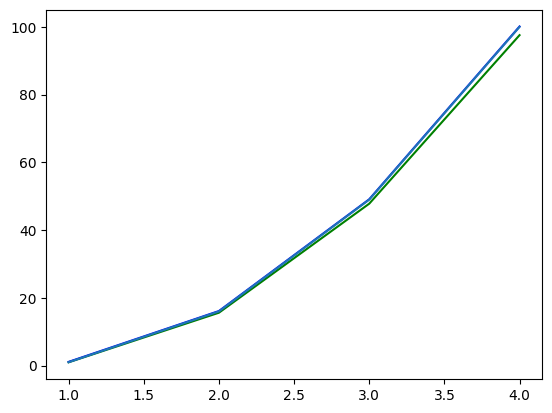

In [325]:
fig, ax = plt.subplots()
def plot_data(ax, mus, stds, color='g'):
    ax.plot( np.linspace( 1, N_train, N_train ), mus, color )
    ax.fill_between( np.linspace( 1, N_train, N_train ), mus-1.96*stds, mus+1.96*stds, facecolor=color, alpha=0.3) #, 'g', alpha=0.5 )
    return ax
ax = plot_data(ax, mus, stds, color='g')
ax = plot_data(ax, mus_opt, stds_opt, color='b')
ax.plot(np.linspace( 1, N_train, N_train ), ytrain)

In [303]:
n = xtrain.shape[1]
Sigma = 0.01 * jnp.eye(n)
Mu = xtrain[[0],:]
def compute_qs(Mu, Sigma, xtrain, params):
    alpha = params[0]
    ls = params[1:]
    Lambda = jnp.diag(ls)
    Lambda_inv = jnp.diag(1/ls)
    Sigma_Lambda_inv = jnp.linalg.inv( Sigma + Lambda )
    q = jnp.zeros(N_train)
    def body(i, inputs):
        q = inputs
        kern = alpha**2 / jnp.sqrt(jnp.linalg.det( Sigma @ Lambda_inv + jnp.eye(n) )) * jnp.exp( -0.5 * (xtrain[[i],:]-Mu) @ Sigma_Lambda_inv @ (xtrain[[i],:]-Mu).T )[0,0]
        q = q.at[i].set( kern )
        return q
    q = jax.lax.fori_loop( 0, N_train, body, q )
    return q
def compute_beta(xtrain, ytrain, params):
    cov = train_covariance(xtrain, params)
    # u, s, v = jnp.linalg.svd(cov)
    # sqrtcov = jnp.dot(u, jnp.sqrt(jnp.diag(s)))
    invcov = jnp.linalg.pinv(cov + jnp.diag(noise_var*jnp.ones(N_train)))
    return invcov @ ytrain, invcov
def compute_multivariate_mean( Mu, Sigma, xtrain, ytrain, params ):
    num_gps = ytrain.shape[1]
    mu = jnp.zeros(num_gps)
    def body(i, inputs):
        mu = inputs
        q = compute_qs(Mu, Sigma, xtrain, params[:,i]).reshape(-1,1)
        beta, _ = compute_beta(xtrain, ytrain[:,[i]], params[:,i])
        # jax.debug.print("🤯 {x} 🤯", x=beta.T @ q)
        mu = mu.at[i].set( (beta.T @ q)[0,0] )
        return mu
    mu = jax.lax.fori_loop( 0, num_gps, body, mu )
    return mu
    

In [304]:
print(compute_qs(Mu, Sigma, xtrain, params))
# print(compute_beta(xtrain, ytrain, params))
print(compute_multivariate_mean(Mu, Sigma, xtrain, ytrain, params.reshape(-1,1)))

[40846.133 39924.63  37282.984 33262.918]
[1.0791016]


In [334]:
def compute_Qmatrix_for_given_ab(Mu, Sigma, xtrain, ytrain_a, ytrain_b, params_a, params_b):
    
    N_train = xtrain.shape[0]
    alpha_a = params_a[0]
    alpha_b = params_b[0]
    la = params_a[1:]
    lb = params_b[1:]
    Lambda_a = jnp.diag(la)
    Lambda_inv_a = jnp.diag(1/la)
    Lambda_inv_ab = jnp.diag( 1/(la+lb) )
    Lambda_inv_ab_Sigma_inv = jnp.linalg.inv(Lambda_inv_ab + Sigma)
    Lambda_b = jnp.diag(lb)
    Lambda_inv_b = jnp.diag(1/lb)
    R = Sigma @ ( Lambda_inv_a + Lambda_inv_b ) + jnp.eye(n)
    R_term = 1.0/jnp.sqrt( jnp.linalg.det(R) )
    jax.debug.print("🤯 Rterm {x} 🤯 ", x=R_term)
    Rinv = jnp.linalg.inv(R)

    Q = jnp.zeros((N_train, N_train))
    def body_i(i, inputs_i):

        Q = inputs_i
        def body_j(j, inputs_j):
            Q, i = inputs_j            
            zeta_i = (xtrain[[i],:] - Mu).T
            zeta_j = (xtrain[[j],:] - Mu).T
            z_ij = Lambda_inv_a @ zeta_i + Lambda_inv_b @ zeta_j
            n_ij = 2 * ( jnp.log(alpha_a) + jnp.log(alpha_b) )  - (  zeta_i.T @ Lambda_inv_a @ zeta_i + zeta_j.T @ Lambda_inv_b @ zeta_j - z_ij @ Rinv @ Sigma @ z_ij  )[0,0] / 2
            # jax.debug.print("🤯 nij = {x} 🤯, {y}, alpha term: {z}", x=n_ij, y=z_ij.T @ Rinv @ Sigma * z_ij, z= jnp.log(alpha_a) + jnp.log(alpha_b) )
            # Q = Q.at[i,j].set( jnp.exp(n_ij**2) * R_term )
            # jax.debug.print("🤯 Qij_org = {x}", x=Q[i,j])
            # Qij = kernel(xtrain[[i],:], Mu, params_a) * kernel( xtrain[[j],:], Mu, params_b ) * R_term * jnp.exp( z_ij.T @ Rinv @ Sigma * z_ij )
            # jax.debug.print("🤯 nij = {x} 🤯, params {y}, {z}", x=Qij, y=params_a, z=params_b)

            xi = xtrain[[i],:].T
            xj = xtrain[[i],:].T
            zij = Lambda_b @ Lambda_inv_ab @ xi + Lambda_a @ Lambda_inv_ab @ xj
            Qij = alpha_a**2 * alpha_b**2 * R_term * jnp.exp( -0.5 * ( (xi-xj).T @ Lambda_inv_ab @ (xi-xj)  ) ) * jnp.exp( -0.5 * (zij-Mu.T).T @ Lambda_inv_ab_Sigma_inv @ (zij-Mu.T) )
            jax.debug.print("🤯 Qij = {x} 🤯, params {y}, {z}", x=Qij, y=params_a, z=params_b)
            Q = Q.at[i,j].set( Qij[0,0] )

            return Q, i
        Q, _ = jax.lax.fori_loop( 0, N_train, body_j, (Q, i) )
        return Q
    Q = jax.lax.fori_loop( 0, N_train, body_i, Q )
    return Q

def compute_multivariate_cov(Mu, Sigma, xtrain, ytrain, params, multivariate_mu):

    num_gps = ytrain.shape[1]

    out_cov = jnp.eye(num_gps)
    def body_a( a, inputs_a ):
        out_cov = inputs_a

        def body_b(b, inputs_b):
            out_cov, a = inputs_b
            beta_a, invcov_a = compute_beta( xtrain, ytrain[:,[a]], params[:,a] )
            beta_b, invcov_b = compute_beta( xtrain, ytrain[:,[b]], params[:,b] )
            Q = compute_Qmatrix_for_given_ab( Mu, Sigma, xtrain, ytrain[:,[a]], ytrain[:,[b]], params[:,a], params[:,b]  )
            cov = beta_a.T @ Q @ beta_b - multivariate_mu[a] * multivariate_mu[b]
            extra_term = params[0,a]**2 - jnp.trace( invcov_a @ Q )
            jax.debug.print("🤯 {x} 🤯 Q={q}", x=cov, q=Q)
            cov = jax.lax.cond( a==b, lambda x, y: x + y, lambda x, y: x, cov, extra_term )
            out_cov = out_cov.at[a,b].set( cov[0,0] )
            return out_cov, a
        out_cov, _ = jax.lax.fori_loop( 0, num_gps, body_b, (out_cov, a) )
        return out_cov
    out_cov = jax.lax.fori_loop( 0, num_gps, body_a, out_cov )
    return out_cov
            





In [335]:
m_mu = compute_multivariate_mean(Mu, Sigma, xtrain, ytrain, params.reshape(-1,1))
print(compute_multivariate_cov(Mu, Sigma, xtrain, ytrain, params.reshape(-1,1), m_mu))

🤯 Rterm 0.9999493360519409 🤯 
🤯 Qij_org = inf
🤯 Qij = [[1.6684063e+09]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[1.6684063e+09]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[1.6684063e+09]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[1.6684063e+09]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[0.]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[0.]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[0.]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[0.]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[0.]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[0.]] 🤯, params [202.10681 197.19604], [202.10681 197.19604]
🤯 Qij_org = inf
🤯 Qij = [[0.]] 🤯, params [202.10681 197.19604], [2